In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Found 26 images: ['A.jpg', 'B.jpg', 'C.jpg', 'D.jpg', 'F.jpg', 'E.jpg', 'G.jpg', 'I.jpg', 'H.jpg', 'K.jpg', 'J.jpg', 'L.jpg', 'M.jpg', 'N.jpg', 'O.jpg', 'P.jpg', 'R.jpg', 'Q.jpg', 'V.jpg', 'U.jpg', 'T.jpg', 'W.jpg', 'X.jpg', 'Y.jpg', 'Z.jpg', 'S.jpg']
Loaded 26 images.
Extracted features for 26 images.
✅ Features saved to /content/asl_features_no_ml_drive.csv


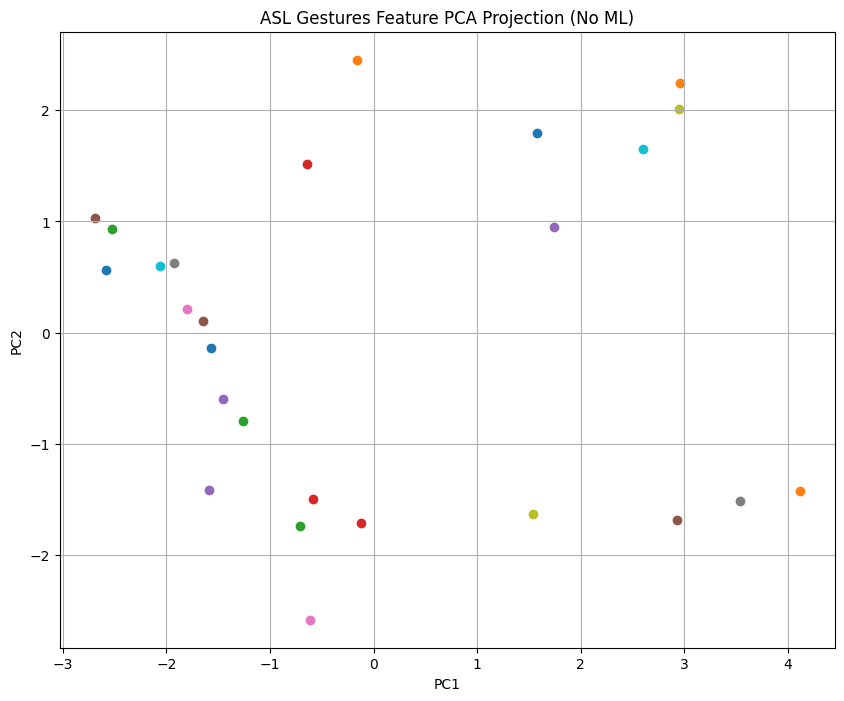

In [ ]:
# ==============================
# ASL Hand Gesture Feature Extraction — Strictly No ML (Drive Folder)
# ==============================

import cv2
import numpy as np
import math
import os
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
from google.colab import drive



# -------- Step 1: Set folder path --------
# Change this path to your ASL images folder
folder_path = '/content/drive/MyDrive/ASL/ASL'

# List all image files in the folder
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png','.jpg','.jpeg'))]
print(f"Found {len(image_files)} images:", image_files)

# -------- Step 2: Load images --------
images = []
labels = []

for img_name in image_files:
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        images.append(img)
        labels.append(img_name.split('.')[0])  # filename as label

print(f"Loaded {len(images)} images.")

# -------- Step 3: Feature Extraction Function --------
def extract_hand_features(frame):
    roi = frame.copy()
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)

    mask_hsv = cv2.inRange(hsv, np.array([0,10,60]), np.array([20,150,255]))
    mask_ycrcb = cv2.inRange(ycrcb, np.array([0,133,77]), np.array([255,173,127]))
    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.GaussianBlur(mask, (5,5), 0)

    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours)==0:
        return None

    cnt = max(contours, key=lambda x: cv2.contourArea(x))
    hull = cv2.convexHull(cnt)
    hull_indices = cv2.convexHull(cnt, returnPoints=False)

    area = cv2.contourArea(cnt)
    hull_area = cv2.contourArea(hull)
    x, y, w, h = cv2.boundingRect(cnt)
    perimeter = cv2.arcLength(cnt, True)

    solidity = area/hull_area if hull_area>0 else 0
    circularity = (4*math.pi*area)/(perimeter**2) if perimeter>0 else 0
    aspect_ratio = w/h if h>0 else 0
    extent = area/(w*h) if w*h>0 else 0

    try:
        (_, _), (_, _), angle = cv2.fitEllipse(cnt)
    except:
        angle = 0

    defect_count = 0
    defect_depths = []
    if hull_indices is not None and len(hull_indices)>3:
        defects = cv2.convexityDefects(cnt, hull_indices)
        if defects is not None:
            for i in range(defects.shape[0]):
                s,e,f,d = defects[i,0]
                start = tuple(cnt[s][0])
                end = tuple(cnt[e][0])
                far = tuple(cnt[f][0])
                a = math.dist(start,end)
                b = math.dist(start,far)
                c = math.dist(end,far)
                angle_defect = math.acos((b**2+c**2-a**2)/(2*b*c))*57
                d_norm = d/perimeter
                if far[1]<y+h*0.9 and angle_defect<=80 and d_norm>0.05:
                    defect_count+=1
                    defect_depths.append(d_norm)

    mean_depth = np.mean(defect_depths) if defect_depths else 0
    max_depth = np.max(defect_depths) if defect_depths else 0
    min_depth = np.min(defect_depths) if defect_depths else 0

    features = [
        defect_count,
        mean_depth,
        max_depth,
        min_depth,
        solidity,
        circularity,
        aspect_ratio,
        extent,
        angle
    ]
    return features

# -------- Step 4: Extract Features for All Images --------
feature_list = []
valid_labels = []

for img,label in zip(images,labels):
    feats = extract_hand_features(img)
    if feats is not None:
        feature_list.append(feats)
        valid_labels.append(label)

features = np.array(feature_list)
print(f"Extracted features for {len(features)} images.")

# -------- Step 5: Save Features to CSV --------
df = pd.DataFrame(features, columns=[
    'defect_count','mean_depth','max_depth','min_depth',
    'solidity','circularity','aspect_ratio','extent','angle'
])
df['label'] = valid_labels
csv_path = '/content/asl_features_no_ml_drive.csv'
df.to_csv(csv_path, index=False)
print(f"✅ Features saved to {csv_path}")

# -------- Step 6: PCA Visualization (Optional) --------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(10,8))
for i,label in enumerate(valid_labels):
    plt.scatter(features_pca[i,0], features_pca[i,1], label=label)
plt.title("ASL Gestures Feature PCA Projection (No ML)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


Saving O.jpg to O.jpg
Detected Gesture: Fist (A,S,M)


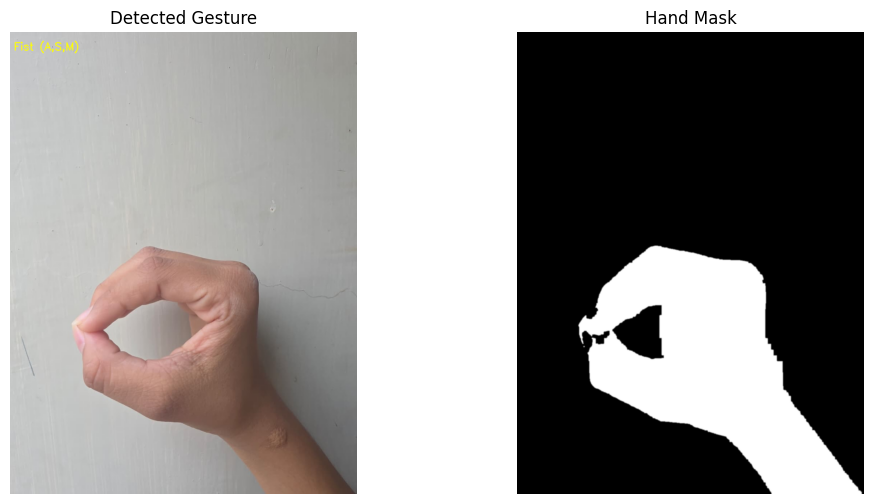

In [ ]:
# ==============================
# Robust ASL Hand Gesture Detection — Rule-Based, No ML
# ==============================

import cv2
import numpy as np
import math
import os
from google.colab import drive

# -------- Step 0: Mount Drive if needed --------
# drive.mount('/content/drive')
# folder_path = '/content/drive/MyDrive/ASL_Images'

# For testing, you can also use files.upload() if not using Drive
# from google.colab import files
# uploaded = files.upload()

# -------- Step 1: Hand Feature Extraction --------
def extract_hand_features(frame):
    roi = frame.copy()

    # Skin detection (HSV + YCrCb)
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)

    mask_hsv = cv2.inRange(hsv, np.array([0,10,60]), np.array([20,150,255]))
    mask_ycrcb = cv2.inRange(ycrcb, np.array([0,133,77]), np.array([255,173,127]))
    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    # Morphology
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.GaussianBlur(mask, (5,5), 0)

    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None, None, None

    cnt = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(cnt)
    hull_indices = cv2.convexHull(cnt, returnPoints=False)

    # Geometric features
    area = cv2.contourArea(cnt)
    hull_area = cv2.contourArea(hull)
    x,y,w,h = cv2.boundingRect(cnt)
    perimeter = cv2.arcLength(cnt, True)

    solidity = area/hull_area if hull_area>0 else 0
    circularity = (4*math.pi*area)/(perimeter**2) if perimeter>0 else 0
    aspect_ratio = w/h if h>0 else 0
    extent = area/(w*h) if w*h>0 else 0

    # Palm center (approx)
    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
    else:
        cx, cy = w//2, h//2

    # Detect convexity defects for fingers
    finger_count = 0
    finger_defects = []
    if hull_indices is not None and len(hull_indices) > 3:
        defects = cv2.convexityDefects(cnt, hull_indices)
        if defects is not None:
            for i in range(defects.shape[0]):
                s,e,f,d = defects[i,0]
                start = tuple(cnt[s][0])
                end = tuple(cnt[e][0])
                far = tuple(cnt[f][0])
                a = math.dist(start,end)
                b = math.dist(start,far)
                c = math.dist(end,far)
                angle_defect = math.acos((b**2 + c**2 - a**2)/(2*b*c))*57
                d_norm = d/perimeter

                # Only consider defects above wrist (bottom 10% of bounding box)
                if far[1] < y+h*0.9 and angle_defect <= 80 and d_norm>0.05:
                    finger_count +=1
                    finger_defects.append(far)

    # The number of fingers is roughly defects + 1
    finger_count = min(finger_count+1,5)  # max 5 fingers

    features = {
        'finger_count': finger_count,
        'solidity': solidity,
        'circularity': circularity,
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'palm_center': (cx,cy),
        'contour': cnt,
        'mask': mask
    }

    return features, roi, mask

# -------- Step 2: Gesture Classification --------
def classify_gesture(features):
    f = features
    fingers = f['finger_count']
    s = f['solidity']
    c = f['circularity']
    ar = f['aspect_ratio']
    ext = f['extent']

    gesture = "Unknown"

    # Deterministic rules
    if fingers == 0 or s > 0.8:
        gesture = "Fist (A,S,M)"
    elif fingers == 1:
        gesture = "One Finger / Pointing (D,E,I,J)"
    elif fingers == 2:
        gesture = "Two Fingers / V Sign (V,U)"
    elif fingers >= 4 and s>0.9 and ar>0.8:
        gesture = "Open Palm (B,5)"
    elif c > 0.7 and ar < 1.2:
        gesture = "C / O Shape (C,O)"
    else:
        gesture = f"Complex Gesture (finger_count={fingers})"

    return gesture

# -------- Step 3: Example Usage --------
# frame = cv2.imread('/content/drive/MyDrive/ASL_Images/A.jpg')
# or upload a file manually
from google.colab import files
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
frame = cv2.imdecode(np.frombuffer(uploaded[img_name], np.uint8), cv2.IMREAD_COLOR)

features, roi, mask = extract_hand_features(frame)
if features is not None:
    gesture = classify_gesture(features)
    print("Detected Gesture:", gesture)

    # Optional: visualize
    cv2.putText(roi, gesture, (10,50), cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,255),2)
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("Detected Gesture")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Hand Mask")
    plt.axis('off')
    plt.show()
else:
    print("No hand detected.")


Saving F.jpg to F.jpg
Detected ASL Letter Group: B


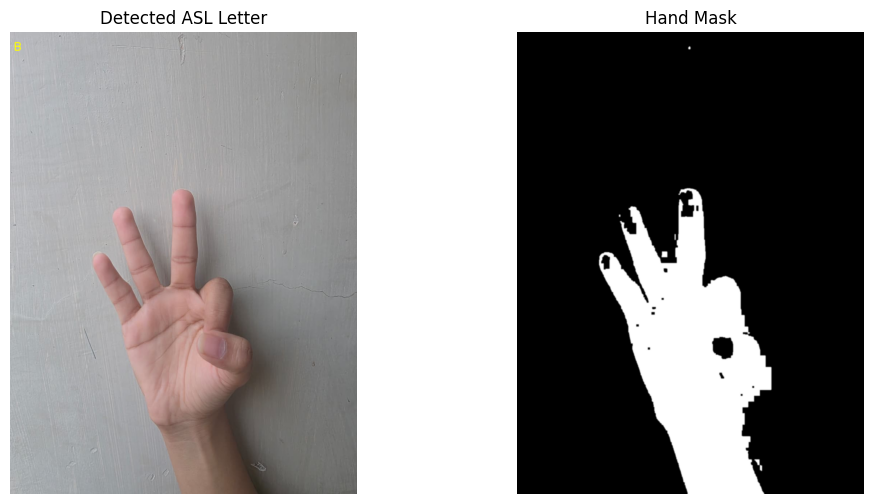

In [38]:
# ==============================
# Full ASL Letter Detection — Robust Rule-Based, No ML
# ==============================

import cv2
import numpy as np
import math
from google.colab import files
import matplotlib.pyplot as plt

# -------- Step 1: Hand Feature Extraction --------
def extract_hand_features(frame):
    roi = frame.copy()

    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    ycrcb = cv2.cvtColor(roi, cv2.COLOR_BGR2YCrCb)
    mask_hsv = cv2.inRange(hsv, np.array([0,10,60]), np.array([20,150,255]))
    mask_ycrcb = cv2.inRange(ycrcb, np.array([0,133,77]), np.array([255,173,127]))
    mask = cv2.bitwise_and(mask_hsv, mask_ycrcb)

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.GaussianBlur(mask, (5,5), 0)

    contours, _ = cv2.findContours(mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours)==0:
        return None, None, None

    cnt = max(contours, key=lambda x: cv2.contourArea(x))
    hull = cv2.convexHull(cnt)
    hull_indices = cv2.convexHull(cnt, returnPoints=False)

    area = cv2.contourArea(cnt)
    hull_area = cv2.contourArea(hull)
    x,y,w,h = cv2.boundingRect(cnt)
    perimeter = cv2.arcLength(cnt, True)

    solidity = area/hull_area if hull_area>0 else 0
    circularity = (4*math.pi*area)/(perimeter**2) if perimeter>0 else 0
    aspect_ratio = w/h if h>0 else 0
    extent = area/(w*h) if w*h>0 else 0

    M = cv2.moments(cnt)
    if M['m00'] != 0:
        cx = int(M['m10']/M['m00'])
        cy = int(M['m01']/M['m00'])
    else:
        cx, cy = w//2, h//2

    # Convexity defects -> finger counting
    finger_count = 0
    defect_depths = []
    if hull_indices is not None and len(hull_indices)>3:
        defects = cv2.convexityDefects(cnt, hull_indices)
        if defects is not None:
            for i in range(defects.shape[0]):
                s,e,f,d = defects[i,0]
                start = tuple(cnt[s][0])
                end = tuple(cnt[e][0])
                far = tuple(cnt[f][0])
                a = math.dist(start,end)
                b = math.dist(start,far)
                c = math.dist(end,far)
                angle_defect = math.acos((b**2 + c**2 - a**2)/(2*b*c))*57
                d_norm = d/perimeter
                # only count valid finger gaps
                if far[1]<y+h*0.9 and angle_defect<=80 and d_norm>0.05:
                    finger_count +=1
                    defect_depths.append(d_norm)
    finger_count = min(finger_count+1,5)

    # Topmost point for D/O distinction
    top_y = np.min(cnt[:,0,1])

    features = {
        'finger_count': finger_count,
        'solidity': solidity,
        'circularity': circularity,
        'aspect_ratio': aspect_ratio,
        'extent': extent,
        'palm_center': (cx,cy),
        'top_y': top_y,
        'contour': cnt,
        'mask': mask,
        'bounding_box': (x,y,w,h)
    }
    return features, roi, mask

# -------- Step 2: Deterministic ASL Letter Classification --------
def classify_asl_letter(features):
    f = features
    fingers = f['finger_count']
    s = f['solidity']
    ar = f['aspect_ratio']
    circ = f['circularity']
    top_y = f['top_y']
    cy = f['palm_center'][1]
    h = f['bounding_box'][3]

    # Rule-based classification
    # Fist letters
    if fingers==0 or s>0.8:
        return "A,S,M"
    # One finger letters
    if fingers==1:
        # D vs others
        if (cy - top_y) > h*0.45 and s<0.95:
            return "D"
        else:
            return "I,J,L"
    # Two fingers
    if fingers==2:
        return "V,U"
    # Three fingers
    if fingers==3:
        return "W"
    # Four fingers
    if fingers==4:
        return "B"  # Open hand minus thumb
    # Five fingers
    if fingers==5:
        # O vs open palm (5)
        if circ > 0.75 and 0.8 < ar < 1.2 and s > 0.85:
            return "O,C"
        else:
            return "5"
    # Default
    return "Complex/Bent Fingers"

# -------- Step 3: Upload image and detect --------
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
frame = cv2.imdecode(np.frombuffer(uploaded[img_name], np.uint8), cv2.IMREAD_COLOR)

features, roi, mask = extract_hand_features(frame)
if features is not None:
    letter = classify_asl_letter(features)
    print("Detected ASL Letter Group:", letter)

    # Optional visualization
    cv2.putText(roi, letter, (10,50), cv2.FONT_HERSHEY_SIMPLEX,1,(0,255,255),2)
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
    plt.title("Detected ASL Letter")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Hand Mask")
    plt.axis('off')
    plt.show()
else:
    print("No hand detected.")
